In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import yaml
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
import os
sns.set_theme(style="whitegrid")

In [9]:
labeled_df = pd.read_csv('data/gnss_dataset_labeled.csv')
summary_df = pd.read_csv('data/gnss_metrics_summary.csv')

In [10]:
print("Labeled Data Info:")
print(labeled_df.info())
print("\nLabeled Data Head:")
print(labeled_df.head())

Labeled Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 202 entries, 0 to 201
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   block_idx          202 non-null    int64  
 1   time_s             202 non-null    float64
 2   best_prn           202 non-null    int64  
 3   best_doppler       202 non-null    int64  
 4   best_tau_chips     202 non-null    float64
 5   peak_snr           202 non-null    float64
 6   peak_raw           202 non-null    float64
 7   in_phase_lag       202 non-null    float64
 8   correlation_width  202 non-null    float64
 9   label              202 non-null    int64  
 10  label_name         202 non-null    str    
dtypes: float64(6), int64(4), str(1)
memory usage: 17.5 KB
None

Labeled Data Head:
   block_idx  time_s  best_prn  best_doppler  best_tau_chips  peak_snr  \
0         95   0.095        16          8000          701.48  5.275831   
1         15   0.015        23 

In [5]:
print("\nSummary Data Info:")
print(summary_df.info())
print("\nSummary Data Head:")
print(summary_df.head().T)


Summary Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   source               2 non-null      str    
 1   label                2 non-null      int64  
 2   snr_mean             2 non-null      float64
 3   snr_std              2 non-null      float64
 4   snr_max              2 non-null      float64
 5   snr_min              2 non-null      float64
 6   snr_cv               2 non-null      float64
 7   snr_above_threshold  2 non-null      float64
 8   doppler_mean         2 non-null      float64
 9   doppler_std          2 non-null      float64
 10  doppler_rate_mean    2 non-null      float64
 11  doppler_rate_max     2 non-null      int64  
 12  doppler_jumps        2 non-null      int64  
 13  doppler_jump_rate    2 non-null      float64
 14  tau_mean             2 non-null      float64
 15  tau_std              2 non-null    

In [11]:
features_to_plot = ['best_doppler', 'best_tau_chips', 'peak_snr', 'peak_raw', 'in_phase_lag', 'correlation_width']

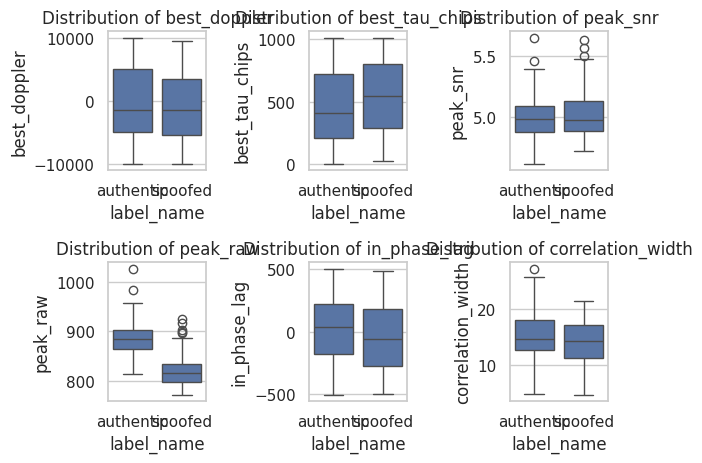

In [12]:
for i, col in enumerate(features_to_plot, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='label_name', y=col, data=labeled_df)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()

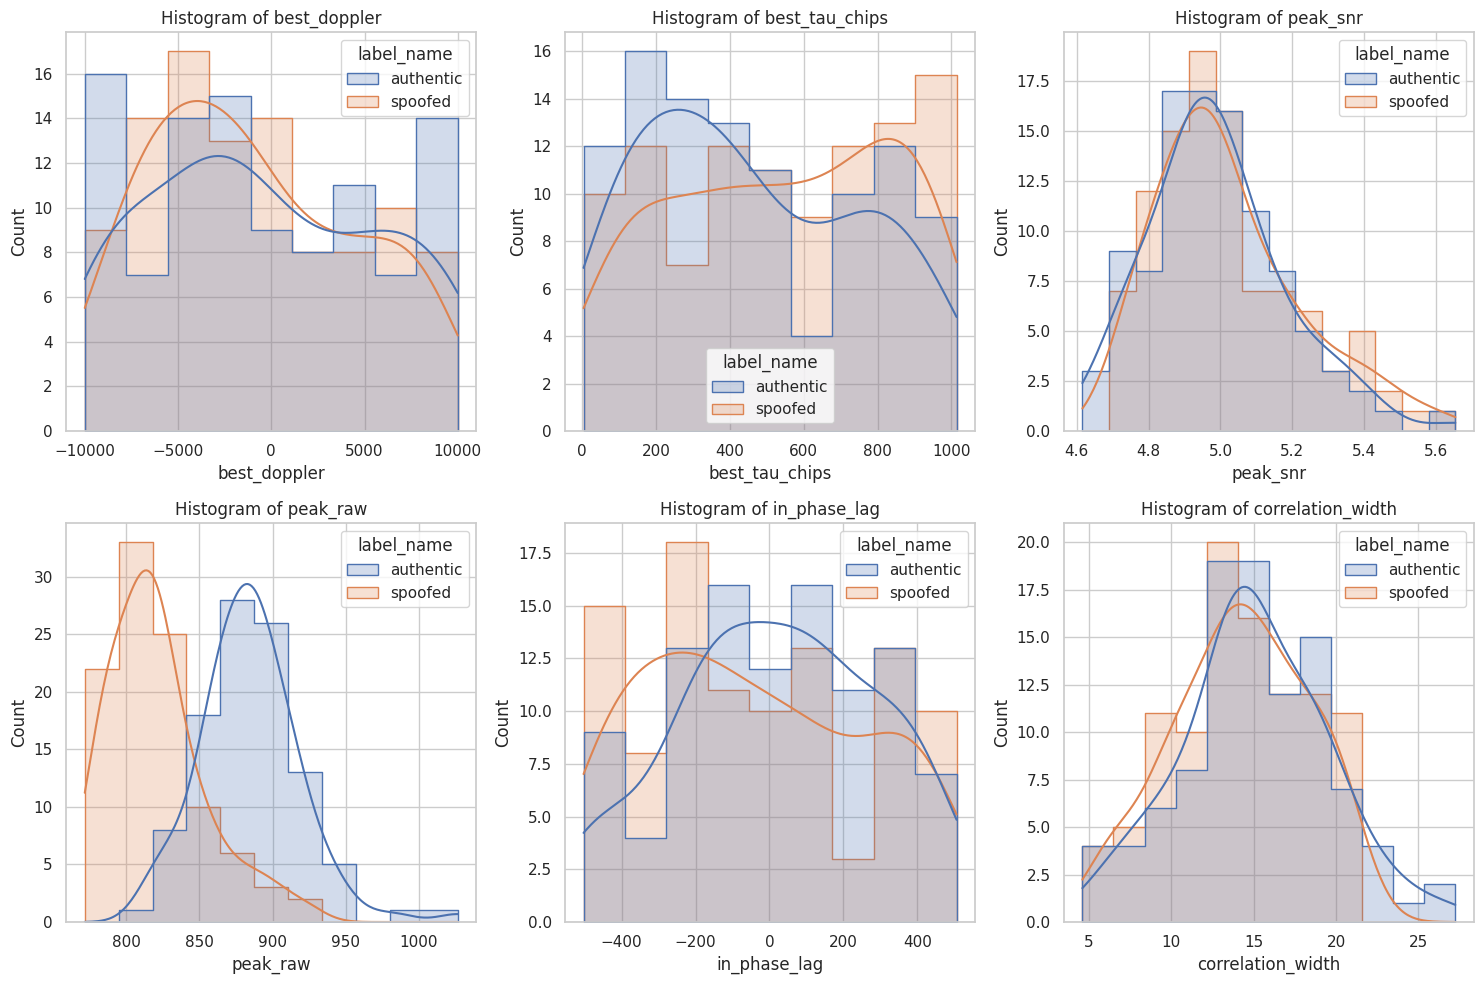

In [13]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(features_to_plot, 1):
    plt.subplot(2, 3, i)
    sns.histplot(data=labeled_df, x=col, hue='label_name', kde=True, element="step")
    plt.title(f'Histogram of {col}')
    plt.tight_layout()

In [14]:
summary_stats = labeled_df.groupby('label_name')[features_to_plot].agg(['mean', 'std']).T
print("Statistical comparison between Clean and Spoofed:")
print(summary_stats)

Statistical comparison between Clean and Spoofed:
label_name                authentic      spoofed
best_doppler      mean  -420.792079  -940.594059
                  std   6146.028259  5478.725732
best_tau_chips    mean   460.029703   543.120792
                  std    297.239334   300.323988
peak_snr          mean     4.989656     5.021031
                  std      0.190991     0.202984
peak_raw          mean   884.697404   820.869685
                  std     34.055893    33.028436
in_phase_lag      mean    20.160396   -42.118812
                  std    267.315579   295.979291
correlation_width mean    15.030891    14.160000
                  std      4.442554     4.082266


In [16]:



X = labeled_df[features_to_plot]
y = labeled_df['label']


rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [18]:
importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': features_to_plot,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

In [21]:
correlations = labeled_df[features_to_plot + ['label']].corr()['label'].drop('label').sort_values(ascending=False)

/tmp/ipykernel_697823/690755334.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


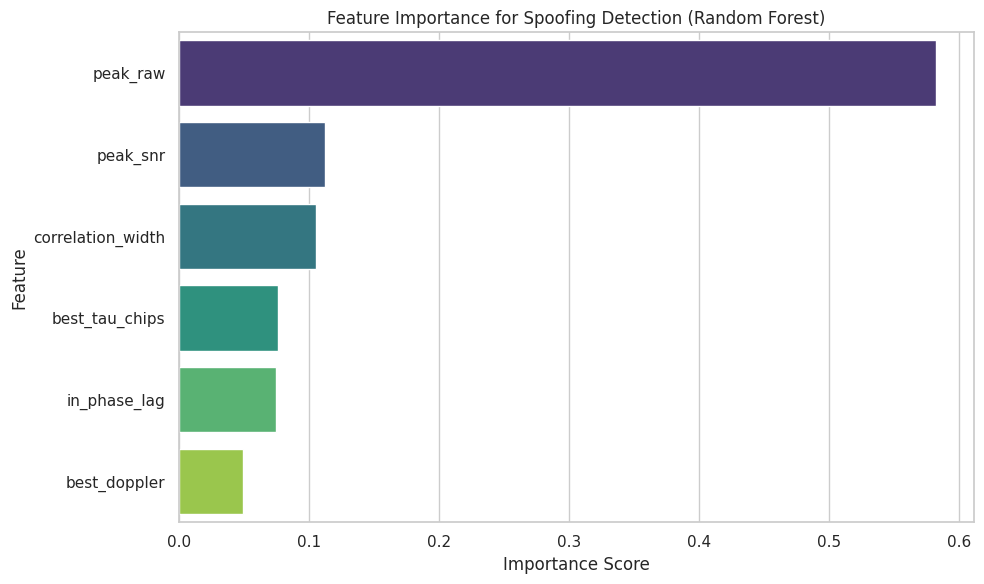

In [22]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance for Spoofing Detection (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()